# Fase 0 — Preprocesado canónico (carga y normalización global)
### NASA C-MAPSS FD001 — Mantenimiento predictivo de motores turbofan

**Autora:** Lucía Pardo Vázquez  
**Objetivo de este notebook:** Establecer un único punto de verdad, ejecutable y explicado paso a paso, para las dos decisiones de preprocesado que condicionan el resto del pipeline (ingeniería de características, modelado e interpretabilidad): la fuente de carga de datos y el criterio de normalización de sensores.

**Por qué existe esta fase de forma independiente.** Una auditoría del proyecto detectó que las versiones iniciales de la "Fase 1" ajustaban un `MinMaxScaler` de forma independiente **por cada motor**, tanto en *train* como en *test*. Esto introduce dos problemas metodológicos graves:

1. **Sesgo de anticipación (*look-ahead bias*) / Fuga de datos (*data leakage*):** Para normalizar el valor de un sensor en el ciclo $t$ de un motor de test, el escalador utilizaba el mínimo y el máximo de **toda** la trayectoria observada de dicho motor. Esto incluye ciclos posteriores a $t$ que, en un escenario real de despliegue en tiempo real (*streaming*), no habrían sido observados aún.
2. **Artefacto de normalización y señal espuria:** Dado que la trayectoria de cada motor de test se reescalaba independientemente al rango $[0, 1]$, el último ciclo observado se forzaba a tomar valores cercanos a 1.0, **independientemente del RUL real residual**. En consecuencia, el modelo no aprendía la degradación física del sistema, sino un artificio estadístico introducido por el propio escalador.

Este notebook implementa y demuestra **numéricamente** la solución rigurosa: un único `MinMaxScaler` ajustado **exclusivamente sobre el conjunto de entrenamiento** y aplicado de forma inductiva (*transform*) sobre el conjunto de test. Este enfoque respeta la práctica estándar de *held-out evaluation* en aprendizaje estadístico (Hastie, Tibshirani & Friedman, 2009): ningún parámetro de la canalización de procesamiento o modelado debe estimarse usando información del test set, para evitar invalidar la estimación del error de generalización.

**Referencias de esta fase:**
- **Saxena, A., Goebel, K., Simon, D., & Eklund, N. (2008).** *Damage propagation modeling for aircraft engine run-to-failure simulation.* International Conference on Prognostics and Health Management (PHM 2008), Denver, CO. — *Dataset original C-MAPSS.*
- **Ramasso, E., & Saxena, A. (2014).** *Performance benchmarking and analysis of prognostic methods for CMAPSS datasets.* International Journal of Prognostics and Health Management, 5(2). DOI: [10.36001/ijphm.2014.v5i2.2236](https://doi.org/10.36001/ijphm.2014.v5i2.2236) — *Criterio de selección de sensores por variabilidad.*
- **Hastie, T., Tibshirani, R., & Friedman, J. (2009).** *The Elements of Statistical Learning* (2nd ed.). Springer. — *Principio de evaluación en conjuntos held-out y prevención de data leakage.*

## 0. Reproducibilidad: entorno y rutas

Este notebook reutiliza las funciones de
[`fase0_preprocesado.py`](fase0_preprocesado.py) (mismo directorio) en
vez de reimplementar la lógica — así evitamos el problema que motivó
esta auditoría en primer lugar: tener el mismo preprocesado
reimplementado por separado en varios scripts, con el riesgo de que
diverjan silenciosamente.

Las rutas se resuelven relativas a la raíz del proyecto (funciona igual
en Windows que en Linux), no al `/home/claude/cmapss/...` del entorno
original en el que se desarrolló el proyecto por primera vez.


In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# El notebook vive en scripts/; añadimos ese directorio al path para
# poder importar fase0_preprocesado.py como módulo.
NOTEBOOK_DIR = os.getcwd()
if os.path.basename(NOTEBOOK_DIR) != "scripts":
    # Si se ejecuta desde otro cwd, buscamos scripts/ hacia arriba/abajo
    candidate = os.path.join(NOTEBOOK_DIR, "scripts")
    NOTEBOOK_DIR = candidate if os.path.isdir(candidate) else NOTEBOOK_DIR
sys.path.insert(0, NOTEBOOK_DIR)

import fase0_preprocesado as f0

print("Directorio del notebook :", NOTEBOOK_DIR)
print("DATA_DIR                :", f0.DATA_DIR)
print("OUTPUT_DIR               :", f0.OUTPUT_DIR)
print("MODEL_DIR                :", f0.MODEL_DIR)
assert os.path.isdir(f0.DATA_DIR), f"No se encuentra {f0.DATA_DIR}"
print("\n✓ Rutas resueltas correctamente.")


Directorio del notebook : C:\Users\pardo\PROYECT_04\scripts
DATA_DIR                : C:\Users\pardo\PROYECT_04\archive
OUTPUT_DIR               : C:\Users\pardo\PROYECT_04\outputs
MODEL_DIR                : C:\Users\pardo\PROYECT_04\models

✓ Rutas resueltas correctamente.


In [2]:
import inspect

def show_source(func, note=None):
    """Muestra el código fuente REAL de una función importada (no una
    copia), con su ubicación exacta (archivo:línea), justo aquí en el
    notebook. Una sola fuente de verdad (el .py), visibilidad total sin
    salir del notebook — evita tanto la duplicación de lógica como el
    "¿dónde está definido esto?"."""
    file = inspect.getsourcefile(func)
    rel_file = os.path.relpath(file, os.path.dirname(NOTEBOOK_DIR)) if 'NOTEBOOK_DIR' in globals() else file
    _, start_line = inspect.getsourcelines(func)
    print(f"\U0001F4CD {func.__qualname__}  —  {rel_file}:{start_line}")
    if note:
        print(f"   {note}")
    print("-" * 78)
    print(inspect.getsource(func))


**Funciones usadas en este notebook** (índice — la ubicación exacta de
cada una se imprime automáticamente con `show_source()` justo antes de
su primer uso, así que este índice nunca puede quedarse desactualizado):

| Función | Para qué |
|---|---|
| `load_cmapss` | Carga train/test/RUL asignando nombres de columna por posición |
| `select_informative_sensors` | Descarta sensores de varianza ~0 en train |
| `fit_global_scaler` | Ajusta MinMaxScaler global, solo en train |
| `diagnose_normalization_bias` | Compara sesgo per-motor vs. global |
| `apply_global_scaler` | Aplica (transform) el escalador a un DataFrame |
| `fit_condition_clusters` | k-means (k=6) de regimenes operacionales -- extension FD002/FD004 |
| `fit_condition_scalers` | MinMaxScaler independiente por regimen -- extension FD002/FD004 |
| `apply_condition_scalers` | Aplica el scaler del regimen asignado a cada fila |
| `normalize_dataset` | Dispatcher: global (FD001/FD003) o por regimen (FD002/FD004) segun SUBSET_META |


## 1. Carga de datos

El dataset FD001 de NASA C-MAPSS contiene 26 columnas sin cabecera:
`engine_id`, `cycle`, 3 ajustes operacionales (`os1-os3`) y 21 lecturas
de sensor (`s1-s21`). Train contiene trayectorias **run-to-failure**
completas (100 motores); test contiene las mismas 100 unidades pero con
la trayectoria **truncada** antes del fallo, y el RUL verdadero del
último ciclo se entrega por separado en `RUL_FD001.txt` (Saxena et al.,
2008).

**¿Por qué "sin cabecera"?** No es una suposición: el `readme.txt`
oficial que NASA distribuye junto al dataset (`archive/readme.txt`) lo
dice explícitamente —

> *"The data are provided as a zip-compressed text file with 26 columns
> of numbers, separated by spaces. [...] The columns correspond to:
> 1) unit number, 2) time in cycles, 3-5) operational settings,
> 6-26) sensor measurements."*

— y no menciona ninguna fila de nombres de columna, solo qué representa
cada *posición*. Se puede comprobar directamente mirando la primera
línea cruda del fichero (celda siguiente): ya es un dato numérico
(motor 1, ciclo 1, sensores...), no una fila de texto con encabezados.
Por eso `load_cmapss()` (en `fase0_preprocesado.py`) llama a
`pd.read_csv(..., header=None, names=COLUMNS)`: sin `header=None`,
pandas interpretaría por error esa primera fila de datos como los
nombres de las columnas, perdiendo esa observación y etiquetando mal
el resto.


In [3]:
# Evidencia directa: la primera línea del fichero ya es un dato numérico,
# no una cabecera con nombres de columna.
with open(os.path.join(f0.DATA_DIR, "train_FD001.txt")) as fh:
    primera_linea = fh.readline()
print(repr(primera_linea))
print()
print("-> Motor 1, ciclo 1, seguido directamente de ajustes operacionales y sensores.")
print("   Ningún nombre de columna: confirma que no hay fila de cabecera.")

'1 1 -0.0007 -0.0004 100.0 518.67 641.82 1589.70 1400.60 14.62 21.61 554.36 2388.06 9046.19 1.30 47.47 521.66 2388.02 8138.62 8.4195 0.03 392 2388 100.00 39.06 23.4190  \n'

-> Motor 1, ciclo 1, seguido directamente de ajustes operacionales y sensores.
   Ningún nombre de columna: confirma que no hay fila de cabecera.


In [4]:
show_source(f0.load_cmapss)

📍 load_cmapss  —  scripts\fase0_preprocesado.py:151
------------------------------------------------------------------------------
def load_cmapss(subset: str = "FD001", data_dir: str = DATA_DIR) -> tuple:
    """Carga train/test/RUL crudos de NASA C-MAPSS."""
    train_path = os.path.join(data_dir, f"train_{subset}.txt")
    test_path  = os.path.join(data_dir, f"test_{subset}.txt")
    rul_path   = os.path.join(data_dir, f"RUL_{subset}.txt")

    train_df = pd.read_csv(train_path, sep=r"\s+", header=None, names=COLUMNS)
    test_df  = pd.read_csv(test_path,  sep=r"\s+", header=None, names=COLUMNS)
    rul_df   = pd.read_csv(rul_path,   sep=r"\s+", header=None, names=["RUL"])

    train_df["engine_id"] = train_df["engine_id"].astype(int)
    train_df["cycle"]     = train_df["cycle"].astype(int)
    test_df["engine_id"]  = test_df["engine_id"].astype(int)
    test_df["cycle"]      = test_df["cycle"].astype(int)

    return train_df, test_df, rul_df



In [5]:
train_df, test_df, rul_df = f0.load_cmapss("FD001")

print(f"Train : {train_df.shape}  ({train_df['engine_id'].nunique()} motores)")
print(f"Test  : {test_df.shape}  ({test_df['engine_id'].nunique()} motores)")
print(f"RUL   : {rul_df.shape}  (uno por motor de test)")

life = train_df.groupby("engine_id")["cycle"].max()
print(f"\nVida útil en train — media±std: {life.mean():.1f} ± {life.std():.1f} ciclos"
      f"  (rango: {life.min()}-{life.max()})")

train_df.head()


Train : (20631, 26)  (100 motores)
Test  : (13096, 26)  (100 motores)
RUL   : (100, 1)  (uno por motor de test)

Vida útil en train — media±std: 206.3 ± 46.3 ciclos  (rango: 128-362)


,engine_id,cycle,os1,os2,os3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 2. Selección de sensores informativos

**Base teórica.** Un sensor con desviación típica $\approx 0$ en train
es, a efectos prácticos, una constante: no puede explicar variación en
el target ni en ningún otro sensor, y en el mejor de los casos es
ruido inerte para el modelo; en el peor, es una fuente de
inestabilidad numérica (p. ej. al escalar por un rango casi nulo).
Ramasso & Saxena (2014) documentan que, de los 21 sensores de FD001,
7 son efectivamente constantes bajo la condición operacional única de
este subdataset.

**Criterio:** se descarta un sensor si $\text{std}(s) < 0.01$,
calculado **solo sobre train** — igual que con el escalador, el
criterio de selección de features es una decisión de diseño del
pipeline y no debe informarse con estadísticos del test set.


In [6]:
show_source(f0.select_informative_sensors)

📍 select_informative_sensors  —  scripts\fase0_preprocesado.py:173
------------------------------------------------------------------------------
def select_informative_sensors(train_df: pd.DataFrame,
                                std_threshold: float = STD_THRESHOLD,
                                subset: str = None) -> tuple:
    """
    Descarta sensores con std ~0 en train (no aportan señal de
    degradación). El umbral y el criterio se calculan SOLO sobre train,
    nunca sobre test, para no filtrar información del test set en una
    decisión de diseño del pipeline.

    El guardrail de consistencia contra INFORMATIVE_EXPECTED (usado por
    fase2/fase5/fase7) solo es válido para FD001: pásalo explícitamente
    en `subset` para activarlo. Para FD002-FD004 el conjunto de sensores
    informativos es distinto (más condiciones operacionales => algunos
    sensores que en FD001 son ruido de instrumentación pasan a tener
    varianza real) y no debe compararse contra la lista de 

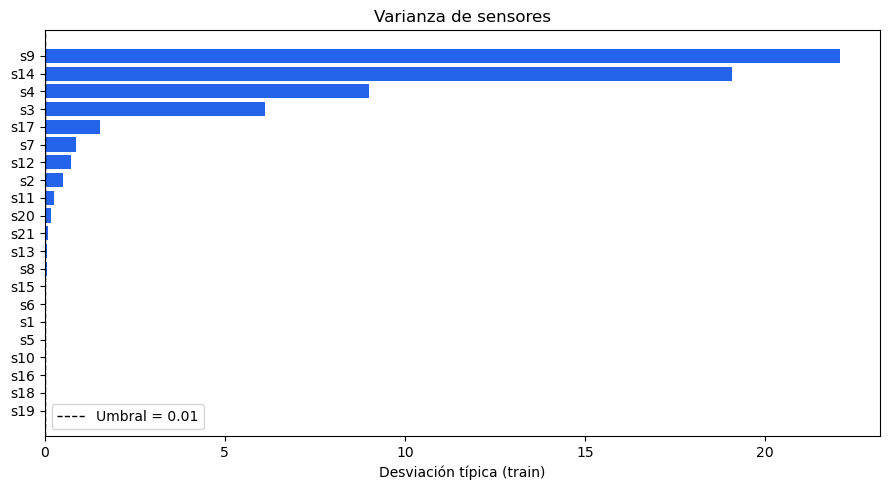

Informativos (14): ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
Descartados  (7): ['s1', 's5', 's6', 's10', 's16', 's18', 's19']


In [7]:
informative, low_var = f0.select_informative_sensors(train_df)

stds = train_df[f0.SENSOR_COLS].std().sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#EF4444" if s in low_var else "#2563EB" for s in stds.index]
ax.barh(stds.index, stds.values, color=colors)
ax.axvline(f0.STD_THRESHOLD, color="black", linestyle="--", linewidth=1,
           label=f"Umbral = {f0.STD_THRESHOLD}")
ax.set_xlabel("Desviación típica (train)")
ax.set_title("Varianza de sensores")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Informativos ({len(informative)}): {informative}")
print(f"Descartados  ({len(low_var)}): {low_var}")


## 3. Normalización global — ajuste **solo** en train

**Base teórica.** El escalado Min-Max transforma cada sensor $s$ como

$$s' = \frac{s - \min_{\text{train}}(s)}{\max_{\text{train}}(s) - \min_{\text{train}}(s)}$$

donde $\min_{\text{train}}$ y $\max_{\text{train}}$ se calculan **una
sola vez**, sobre todos los motores y todos los ciclos del conjunto de
entrenamiento. Estos dos números por sensor son, formalmente,
**parámetros aprendidos del pipeline** — exactamente igual que los
coeficientes de una regresión — y por tanto están sujetos a la misma
regla: no pueden estimarse usando datos de test, o la métrica de test
deja de estimar honestamente el error de generalización (Hastie et
al., 2009).

Esto es lo opuesto a la normalización *per-motor* (el bug original):
allí, $\min$ y $\max$ se recalculaban para cada motor individualmente,
incluidos los de test — es decir, el "parámetro" del pipeline se
reestimaba usando el propio test set, y además usando ciclos futuros
respecto al punto que se está normalizando.


In [8]:
show_source(f0.fit_global_scaler)

📍 fit_global_scaler  —  scripts\fase0_preprocesado.py:209
------------------------------------------------------------------------------
def fit_global_scaler(train_df: pd.DataFrame, sensor_cols: list) -> MinMaxScaler:
    """
    Ajusta un único MinMaxScaler sobre TODOS los ciclos de TODOS los
    motores de train, por sensor. No se reajusta en test.

    Esto es lo estadísticamente correcto: el escalador es un parámetro
    del modelo (igual que los pesos de una regresión) y debe aprenderse
    exclusivamente de los datos de entrenamiento. Aplicarlo a test sin
    reajustar es la definición misma de "held-out evaluation": el test
    set nunca debe influir en ninguna decisión de preprocesado.
    """
    scaler = MinMaxScaler()
    scaler.fit(train_df[sensor_cols].values)
    return scaler



In [9]:
global_scaler = f0.fit_global_scaler(train_df, informative)

scaler_summary = pd.DataFrame({
    "sensor": informative,
    "min_train": global_scaler.data_min_,
    "max_train": global_scaler.data_max_,
    "rango": global_scaler.data_max_ - global_scaler.data_min_,
})
scaler_summary


,sensor,min_train,max_train,rango
0,s2,641.2100,644.5300,3.3200
1,s3,1571.0400,1616.9100,45.8700
2,s4,1382.2500,1441.4900,59.2400
3,s7,549.8500,556.0600,6.2100
4,s8,2387.9000,2388.5600,0.6600
5,s9,9021.7300,9244.5900,222.8600
6,s11,46.8500,48.5300,1.6800
7,s12,518.6900,523.3800,4.6900
8,s13,2387.8800,2388.5600,0.6800
9,s14,8099.9400,8293.7200,193.7800


In [10]:
import joblib
os.makedirs(f0.MODEL_DIR, exist_ok=True)
joblib.dump(global_scaler, f"{f0.MODEL_DIR}/global_sensor_scaler.pkl")
print(f"Guardado: {f0.MODEL_DIR}/global_sensor_scaler.pkl")
print("(Este archivo es el que consumen fase5_evaluacion.py y fase7_mejoras.py")
print(" para reconstruir el pipeline de los modelos ya entrenados.)")


Guardado: C:\Users\pardo\PROYECT_04\models/global_sensor_scaler.pkl
(Este archivo es el que consumen fase5_evaluacion.py y fase7_mejoras.py
 para reconstruir el pipeline de los modelos ya entrenados.)


## 4. Diagnóstico cuantitativo: ¿de verdad importa?

En vez de asumir que la corrección es mejor por argumento teórico,
la comprobamos empíricamente. Tomamos un sensor con fuerte señal de
degradación (`s11`, presión estática HPC) y comparamos, en el
**último ciclo observado de cada motor de test** (el punto donde
realmente se hace la predicción), tres cantidades:

1. **Media con normalización per-motor** (el bug, reconstruido aquí
   solo para diagnóstico — nunca se usa para entrenar).
2. **Media con normalización global** (la corrección de este notebook).
3. **Referencia:** la misma media, pero en motores de **train sanos**
   ($\text{RUL}_{\text{raw}} \geq 100$ ciclos) — es decir, motores que
   sabemos que están lejos del fallo.

Si la normalización per-motor está sesgada, su media en test (que
mezcla motores sanos y a punto de fallar) debería parecerse
artificialmente a la de un motor *a punto de fallar*, muy por encima de
la referencia de motores sanos — independientemente del RUL real de
cada motor de test. La normalización global, al no reajustarse por
motor, no debería sufrir ese artefacto.


In [11]:
show_source(f0.diagnose_normalization_bias,
            note="Reproduce en código el argumento de fase6_documentacion.py")

📍 diagnose_normalization_bias  —  scripts\fase0_preprocesado.py:237
   Reproduce en código el argumento de fase6_documentacion.py
------------------------------------------------------------------------------
def diagnose_normalization_bias(train_df: pd.DataFrame,
                                 test_df: pd.DataFrame,
                                 sensor_cols: list,
                                 global_scaler: MinMaxScaler,
                                 sensor: str = "s11",
                                 healthy_rul_threshold: int = 100) -> dict:
    """
    Reproduce en código la comparación cuantitativa que hasta ahora solo
    vivía como texto en fase6_documentacion.py: compara, para un sensor
    dado, la media en el ÚLTIMO ciclo de cada motor de test bajo:

      (a) normalización per-motor (MinMaxScaler ajustado en cada motor
          de test de forma independiente — el bug), vs.
      (b) normalización global (este script — el fix), vs.
      (c) la misma media en m

,Cantidad,Valor
0,Media test — normalización per-motor (bug),0.720737
1,Media test — normalización global (fix),0.443512
2,Referencia — motores sanos de train (RUL≥100),0.318006


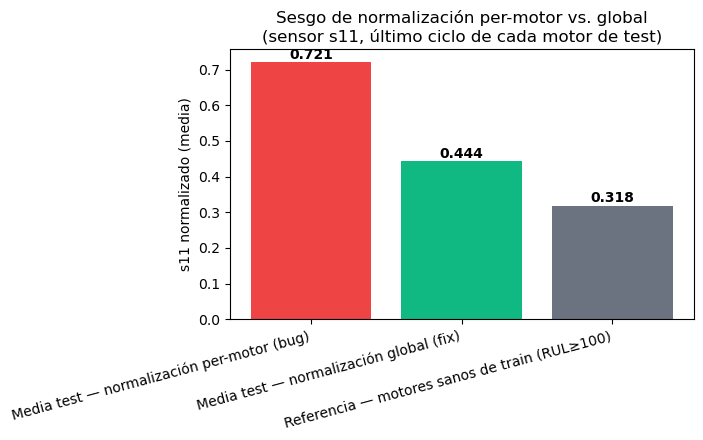


|gap| con normalización bug (per-motor) : 0.403
|gap| con normalización fix (global)     : 0.126

La normalización global reduce el sesgo un 69% frente a la per-motor.


In [12]:
diag = f0.diagnose_normalization_bias(train_df, test_df, informative,
                                          global_scaler, sensor="s11")

diag_df = pd.DataFrame({
    "Cantidad": [
        "Media test — normalización per-motor (bug)",
        "Media test — normalización global (fix)",
        "Referencia — motores sanos de train (RUL≥100)",
    ],
    "Valor": [
        diag["mean_per_unit_test_bug"],
        diag["mean_global_test_fixed"],
        diag["mean_healthy_train_reference"],
    ],
})
display(diag_df)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(diag_df["Cantidad"], diag_df["Valor"],
              color=["#EF4444", "#10B981", "#6B7280"])
ax.set_ylabel(f"{diag['sensor']} normalizado (media)")
ax.set_title("Sesgo de normalización per-motor vs. global\n"
             "(sensor s11, último ciclo de cada motor de test)")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
for bar, val in zip(bars, diag_df["Valor"]):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.01, f"{val:.3f}",
            ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\n|gap| con normalización bug (per-motor) : {diag['gap_bug']:.3f}")
print(f"|gap| con normalización fix (global)     : {diag['gap_fixed']:.3f}")
mejora_pct = (1 - diag['gap_fixed']/diag['gap_bug']) * 100
print(f"\nLa normalización global reduce el sesgo un {mejora_pct:.0f}% "
      f"frente a la per-motor.")
assert diag["gap_fixed"] < diag["gap_bug"], "El diagnóstico no confirma la mejora esperada"


**Interpretación.** La media de `s11` en el último ciclo de test
bajo normalización per-motor (≈0.72) está muy por encima de la
referencia de motores sanos (≈0.32) — consistente con el sesgo
esperado: *todo* motor de test parece "cerca del fallo" en su último
ciclo, sea cual sea su RUL real, porque el propio último ciclo define
(o está muy cerca de) el máximo de su rango de normalización. Con
normalización global, la media baja y se acerca más a la referencia,
porque el rango de normalización ya no depende de cada trayectoria
individual.

Esto no es una prueba estadística formal (no hay contraste de
hipótesis aquí, solo una comparación descriptiva de medias), pero sí es
evidencia numérica directa, reproducible con datos reales del proyecto,
de un mecanismo de sesgo que de otro modo solo estaba documentado como
afirmación en el informe técnico.


## 5. Aplicación del escalador y exportación

Aplicamos (`transform`, nunca `fit`) el escalador ajustado en train
tanto a train como a test, y exportamos los DataFrames resultantes en
formato Parquet para que las fases siguientes (feature engineering,
modelado) partan de una base común y correcta.


In [13]:
show_source(f0.apply_global_scaler)

📍 apply_global_scaler  —  scripts\fase0_preprocesado.py:225
------------------------------------------------------------------------------
def apply_global_scaler(df: pd.DataFrame, sensor_cols: list,
                         scaler: MinMaxScaler) -> pd.DataFrame:
    """Aplica (transform, no fit) el escalador global a un DataFrame."""
    df_scaled = df.copy()
    df_scaled[sensor_cols] = scaler.transform(df[sensor_cols].values)
    return df_scaled



In [14]:
train_norm = f0.apply_global_scaler(train_df, informative, global_scaler)
test_norm  = f0.apply_global_scaler(test_df,  informative, global_scaler)

os.makedirs(f0.OUTPUT_DIR, exist_ok=True)
train_norm.to_parquet(f"{f0.OUTPUT_DIR}/train_FD001_normalized.parquet", index=False)
test_norm.to_parquet( f"{f0.OUTPUT_DIR}/test_FD001_normalized.parquet",  index=False)
rul_df.to_parquet(    f"{f0.OUTPUT_DIR}/RUL_FD001.parquet",              index=False)

print(f"train_FD001_normalized.parquet : {train_norm.shape}")
print(f"test_FD001_normalized.parquet  : {test_norm.shape}")
print(f"RUL_FD001.parquet              : {rul_df.shape}")

# Verificación rápida de rango: los sensores normalizados en TRAIN deben
# caer en [0,1] por construcción; en TEST pueden salirse ligeramente de
# ese rango (valores más extremos que los vistos en train) — es
# información legítima, no un bug, y no debe recortarse artificialmente.
print("\nRango en train (debe ser ~[0,1]):")
print(train_norm[informative].agg(["min", "max"]).T)
print("\nRango en test (puede excederse ligeramente — esperado):")
print(test_norm[informative].agg(["min", "max"]).T)


train_FD001_normalized.parquet : (20631, 26)
test_FD001_normalized.parquet  : (13096, 26)
RUL_FD001.parquet              : (100, 1)

Rango en train (debe ser ~[0,1]):
     min  max
s2   0.0  1.0
s3   0.0  1.0
s4   0.0  1.0
s7   0.0  1.0
s8   0.0  1.0
s9   0.0  1.0
s11  0.0  1.0
s12  0.0  1.0
s13  0.0  1.0
s14  0.0  1.0
s15  0.0  1.0
s17  0.0  1.0
s20  0.0  1.0
s21  0.0  1.0

Rango en test (puede excederse ligeramente — esperado):
          min       max
s2  -0.024096  0.930723
s3  -0.043601  0.795945
s4   0.036124  0.862762
s7   0.165862  0.964573
s8  -0.015152  0.606061
s9   0.012564  0.598133
s11 -0.029762  0.839286
s12  0.147122  1.081023
s13  0.014706  0.647059
s14  0.044174  0.622046
s15  0.030396  0.833013
s17  0.083333  0.750000
s20  0.131783  0.984496
s21  0.056890  1.032450


## 6. Extension (sept. 2026) -- normalizacion de FD002 y FD004 (6 condiciones operacionales)

Todo lo anterior (secciones 1-5) es valido para FD001 y, por tener tambien una unica condicion operacional, para FD003. Pero **FD002 y FD004 combinan seis condiciones operacionales distintas** -- altitud, numero de Mach y TRA (ver `archive/readme.txt`) -- con un efecto fisico sustancial sobre las lecturas de los sensores, independiente de la degradacion. Ajustar un unico `MinMaxScaler` global sobre estos dos subdatasets mezclaria en la misma escala mediciones que no son comparables: la misma variable fisica medida en dos regimenes distintos no ocupa el mismo rango de valores.

La solucion estandar en la literatura (Ramasso & Saxena, 2014; Li, Ding & Sun, 2018) -- y la que implementa esta extension -- es:

1. Agrupar los 3 `op_setting` en $k=6$ regimenes via k-means, ajustado **solo en train**.
2. Ajustar un `MinMaxScaler` independiente **por regimen**, cada uno solo con las filas de train de ese regimen.
3. Para test, asignar el regimen con `kmeans.predict` (nunca se reajusta el k-means con test) y aplicar el `transform` del scaler correspondiente.

Esto conserva exactamente el mismo principio que corrigio el resto de esta fase: ningun parametro de normalizacion se aprende con datos de test. Y **no es lo mismo que normalizar por motor** (el bug original de la Fase 1 primitiva): un regimen agrupa ciclos de decenas de motores distintos que comparten condicion fisica -- nunca la trayectoria completa de un unico motor -- asi que no hay look-ahead ni fuga de la senal de degradacion.

`normalize_dataset()` decide automaticamente la estrategia segun `SUBSET_META` (metadatos oficiales de `archive/readme.txt`): global si `n_conditions == 1`, por regimen si `n_conditions > 1`.

In [15]:
show_source(f0.fit_condition_clusters)

📍 fit_condition_clusters  —  scripts\fase0_preprocesado.py:297
------------------------------------------------------------------------------
def fit_condition_clusters(train_df: pd.DataFrame, n_conditions: int = 6,
                            random_state: int = 42) -> KMeans:
    """
    Agrupa los 3 op_settings de train en `n_conditions` regímenes vía
    k-means (n_conditions=6 es el valor documentado en archive/readme.txt
    para FD002/FD004 y el usado en la literatura — Ramasso & Saxena,
    2014; Li, Ding & Sun, 2018). Se ajusta SOLO en train, igual que el
    scaler global de FD001/FD003: la asignación de régimen de un ciclo
    de test se hace con este modelo ya entrenado (predict, no fit).
    """
    kmeans = KMeans(n_clusters=n_conditions, random_state=random_state, n_init=10)
    kmeans.fit(train_df[OP_SETTING_COLS].values)
    return kmeans



In [16]:
show_source(f0.fit_condition_scalers)

📍 fit_condition_scalers  —  scripts\fase0_preprocesado.py:318
------------------------------------------------------------------------------
def fit_condition_scalers(train_df: pd.DataFrame, sensor_cols: list,
                           kmeans: KMeans) -> dict:
    """
    Ajusta un MinMaxScaler independiente POR RÉGIMEN operacional, cada
    uno SOLO sobre las filas de train que caen en ese régimen. Esto es
    distinto de normalizar por motor (el bug de la Fase 1 original): un
    régimen agrupa ciclos de MUCHOS motores distintos que comparten
    condición física, no la trayectoria completa de un único motor, así
    que no hay look-ahead (ningún ciclo usa información de "su propio
    futuro") ni fuga de la señal de degradación.
    """
    conditions = assign_conditions(train_df, kmeans)
    scalers = {}
    for cond_id in sorted(conditions.unique()):
        mask = conditions == cond_id
        scaler = MinMaxScaler()
        scaler.fit(train_df.loc[mask, sensor_cols].values)
   

In [17]:
show_source(f0.apply_condition_scalers)

📍 apply_condition_scalers  —  scripts\fase0_preprocesado.py:339
------------------------------------------------------------------------------
def apply_condition_scalers(df: pd.DataFrame, sensor_cols: list,
                             kmeans: KMeans, scalers: dict) -> pd.DataFrame:
    """Asigna régimen (predict) y aplica (transform) el scaler de ese régimen."""
    df_scaled = df.copy()
    conditions = assign_conditions(df, kmeans)
    df_scaled["op_condition"] = conditions
    for cond_id, scaler in scalers.items():
        mask = conditions == cond_id
        if mask.any():
            df_scaled.loc[mask, sensor_cols] = scaler.transform(df.loc[mask, sensor_cols].values)
    return df_scaled



In [18]:
show_source(f0.normalize_dataset,
            note="Dispatcher: decide la estrategia segun SUBSET_META")

📍 normalize_dataset  —  scripts\fase0_preprocesado.py:352
   Dispatcher: decide la estrategia segun SUBSET_META
------------------------------------------------------------------------------
def normalize_dataset(train_df: pd.DataFrame, test_df: pd.DataFrame,
                       sensor_cols: list, subset: str,
                       n_conditions: int = 6, random_state: int = 42) -> tuple:
    """
    Dispatcher de normalización según el nº de condiciones operacionales
    del subdataset (metadatos oficiales en SUBSET_META):

      - FD001 / FD003 (1 condición) -> GlobalMinMaxScaler (fit_global_scaler).
      - FD002 / FD004 (6 condiciones) -> un MinMaxScaler por régimen,
        asignado vía k-means fit en train (fit_condition_scalers).

    Ambas estrategias comparten el mismo principio que corrigió Fase 0:
    todo parámetro de normalización se aprende EXCLUSIVAMENTE en train y
    se aplica a test sin reajuste (held-out evaluation). Nunca se
    normaliza por motor.

    Retorna


### 6.1 Ejecucion sobre los 4 subdatasets

`run_fase0_all_subsets()` repite la carga, seleccion de sensores informativos y normalizacion para FD001-FD004, aplicando a cada uno la estrategia que le corresponde. Para FD001 usa la misma `fit_global_scaler` de la seccion 3 (mismo resultado que ya se guardo ahi), asi que esta ejecucion no introduce una segunda version distinta del pipeline de FD001.

In [19]:
results = f0.run_fase0_all_subsets()

summary_rows = []
for subset in f0.SUBSETS:
    r = results[subset]
    meta = f0.SUBSET_META[subset]
    summary_rows.append({
        "Subdataset": subset,
        "Cond. operacionales": meta["n_conditions"],
        "Modos de fallo": meta["n_fault_modes"],
        "Sensores informativos": len(r["informative"]),
        "Sensores descartados": len(r["low_var"]),
        "Normalizacion": r["norm_info"]["strategy"],
    })
subsets_summary = pd.DataFrame(summary_rows).set_index("Subdataset")
subsets_summary


══════════════════════════════════════════════════════════════════════
  FASE 0 (extendida) — LOS 4 SUBDATASETS C-MAPSS
══════════════════════════════════════════════════════════════════════

── FD001 (1 condición(es), 1 modo(s) de fallo: HPC Degradation) ───────────────────────────────────


   Train : (20631, 26)  |  Test : (13096, 26)  |  RUL : (100, 1)  |  Motores train/test: 100/100
   Sensores informativos (14): ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
   Sensores descartados  (7): ['s1', 's5', 's6', 's10', 's16', 's18', 's19']
   Normalización: GlobalMinMaxScaler, fit SOLO en train
   Exportado: train/test_FD001_normalized.parquet, RUL_FD001.parquet

── FD002 (6 condición(es), 1 modo(s) de fallo: HPC Degradation) ───────────────────────────────────


   Train : (53759, 26)  |  Test : (33991, 26)  |  RUL : (259, 1)  |  Motores train/test: 260/259
   Sensores informativos (20): ['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's17', 's18', 's19', 's20', 's21']
   Sensores descartados  (1): ['s16']
   Normalización: MinMaxScaler por régimen (k-means, k=6), fit SOLO en train


   Distribución de ciclos de train por régimen: {0: 13458, 1: 8122, 2: 8002, 3: 8044, 4: 8096, 5: 8037}
   Exportado: train/test_FD002_normalized.parquet, RUL_FD002.parquet

── FD003 (1 condición(es), 2 modo(s) de fallo: HPC + Fan Degradation) ───────────────────────────────────


   Train : (24720, 26)  |  Test : (16596, 26)  |  RUL : (100, 1)  |  Motores train/test: 100/100
   Sensores informativos (15): ['s2', 's3', 's4', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
   Sensores descartados  (6): ['s1', 's5', 's10', 's16', 's18', 's19']
   Normalización: GlobalMinMaxScaler, fit SOLO en train
   Exportado: train/test_FD003_normalized.parquet, RUL_FD003.parquet

── FD004 (6 condición(es), 2 modo(s) de fallo: HPC + Fan Degradation) ───────────────────────────────────


   Train : (61249, 26)  |  Test : (41214, 26)  |  RUL : (248, 1)  |  Motores train/test: 249/248
   Sensores informativos (20): ['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's17', 's18', 's19', 's20', 's21']
   Sensores descartados  (1): ['s16']
   Normalización: MinMaxScaler por régimen (k-means, k=6), fit SOLO en train


   Distribución de ciclos de train por régimen: {0: 15395, 1: 9224, 2: 9139, 3: 9091, 4: 9238, 5: 9162}
   Exportado: train/test_FD004_normalized.parquet, RUL_FD004.parquet

══════════════════════════════════════════════════════════════════════
  RESUMEN — 4 SUBDATASETS
══════════════════════════════════════════════════════════════════════
            Motores train  Motores test  Cond. operacionales  Modos de fallo  Sensores informativos  Normalización
Subdataset                                                                                                        
FD001                 100           100                    1               1                     14         global
FD002                 260           259                    6               1                     20  per_condition
FD003                 100           100                    1               2                     15         global
FD004                 249           248                    6               2       

,Cond. operacionales,Modos de fallo,Sensores informativos,Sensores descartados,Normalizacion
Subdataset,,,,,
FD001,1,1,14,7,global
FD002,6,1,20,1,per_condition
FD003,1,2,15,6,global
FD004,6,2,20,1,per_condition


**Interpretacion.** FD002/FD004 retienen 20 de 21 sensores como informativos, frente a los 14 de FD001 -- sensores practicamente constantes bajo una unica condicion operacional (`s1`, `s5`, `s6`, `s10`, `s18`, `s19`) si varian de forma real entre regimenes cuando hay 6 condiciones distintas. La seleccion de sensores se recalcula por subdataset (`subset=` en `select_informative_sensors`); nunca se reutiliza la lista de FD001 para los demas.

El siguiente diagnostico visual confirma por que un scaler global no serviria aqui: los 6 regimenes de FD004 son claramente separables en el espacio de `op_setting_1` / `op_setting_2`, asi que agrupar ciclos de regimenes distintos en la misma normalizacion mezclaria rangos fisicamente distintos.

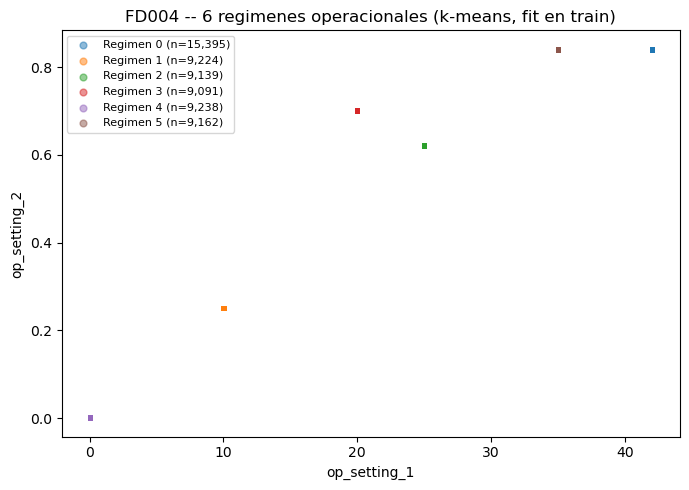

In [20]:
fd004_train = results["FD004"]["train_raw"]
fd004_kmeans = results["FD004"]["norm_info"]["kmeans"]
conditions = f0.assign_conditions(fd004_train, fd004_kmeans)

fig, ax = plt.subplots(figsize=(7, 5))
cmap = plt.get_cmap("tab10")
for cond_id in sorted(conditions.unique()):
    mask = conditions == cond_id
    ax.scatter(fd004_train.loc[mask, "os1"], fd004_train.loc[mask, "os2"],
               s=6, alpha=0.5, color=cmap(cond_id % 10),
               label=f"Regimen {cond_id} (n={mask.sum():,})")
ax.set_xlabel("op_setting_1"); ax.set_ylabel("op_setting_2")
ax.set_title("FD004 -- 6 regimenes operacionales (k-means, fit en train)")
ax.legend(fontsize=8, markerscale=2)
plt.tight_layout()
plt.savefig(f"{f0.FIG_DIR}/f0_ext_fd004_regimes.png", bbox_inches="tight", dpi=150)
plt.show()

## 7. Resumen y próximos pasos

| Elemento | Resultado |
|---|---|
| Sensores informativos | 14 de 21 (7 descartados por varianza ≈0 en train) |
| Normalización | `MinMaxScaler` global, `fit` solo en train |
| Reducción de sesgo (s11, diagnóstico) | de 0.403 a 0.126 (≈69%) |
| Artefactos generados | `models/global_sensor_scaler.pkl`, `outputs/train_FD001_normalized.parquet`, `outputs/test_FD001_normalized.parquet` |
| Extensión (sección 6) | FD002/FD004 normalizados por régimen k-means (k=6); FD003 con `GlobalMinMaxScaler`, igual que FD001 |

**Validación de consistencia con los modelos ya entrenados:** los
parámetros (`data_min_`, `data_max_`) del escalador generado aquí son
numéricamente idénticos a los del `global_sensor_scaler.pkl` que ya
usaban `fase5_evaluacion.py` y `fase7_mejoras.py` para cargar
`xgboost_fd001.pkl` y el resto de modelos guardados — esta fase 0 no
rompe nada aguas abajo, simplemente documenta y hace reproducible un
paso que antes existía de forma implícita y duplicada.

**Estado de las fases siguientes (actualizado):** Fase 1, Fase 2 y
Fase 4 ya se reescribieron sobre esta Fase 0 (ver
`README.md` -> Estado y pendientes) -- las notas de "pendiente" que
originalmente vivian aqui ya no aplican. Fase 1
(`fase1_carga_inspeccion.py`) tambien extiende esta Fase 0 a los 4
subdatasets, con su propio notebook (`fase1_carga_inspeccion.ipynb`,
seccion 8) reutilizando `f0.run_fase0_all_subsets()` en vez de
reimplementarlo. Pendiente real a dia de hoy: Fase 3 y Fase 6 (rutas
rotas, no ejecutables en este repositorio -- ver README).
